In [1]:
import secrets
from typing import Optional
from tqdm import tqdm

import numpy as np

import torch
import torchopt

import nll_to_po.models.dn_policy as Policy
import nll_to_po.models.reward_network as RM
from nll_to_po.training.utils import (
    set_seed_everywhere,
)
import nll_to_po.training.loss as L
import nll_to_po.training.reward as R
import nll_to_po.training.data as Data

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", font_scale=1.2)
sns.set_palette("colorblind")

seed = secrets.randbits(32)
set_seed_everywhere(seed)
print(f"Seed: {seed}")

/mnt/data_2/abenechehab/micromamba/envs/nllpo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed: 3878961254


## Torchopt

### Functional API

In [2]:
# -----------------------
# Helper: make functional params with grad
# -----------------------
def make_functional_with_grads(module):
    params = dict(module.named_parameters())
    params = [p.detach().clone().requires_grad_(True) for _, p in params.items()]
    return module, params


# -----------------------
# Main bilevel routine
# -----------------------
def run_bilevel_optimization(
    X_train,
    y_train,
    X_val,
    y_val,
    n_outer_epochs=10,
    n_inner_epochs=5,
    inner_lr: float = 1e-3,
    outer_lr: float = 1e-3,
    device: str = "cpu",
    input_dim: int = 2,
    output_dim: int = 2,
    hidden_sizes: list[int] = [64, 64],
    fixed_logstd: bool = False,
    entropy_weight: float = 1.0,
    n_generations: int = 5,
    use_batchnorm: bool = False,
    use_layernorm: bool = False,
    outer_scheduler_patience: int = 0,
    early_stopping_patience: int = 0,
    reward_network: Optional[torch.nn.Module] = None,
):
    # reward
    reward_network = reward_network.to(device)
    reward_model, reward_params = make_functional_with_grads(reward_network)

    # reward loss: nll
    nll_loss = L.FuncNLL()

    # Tracking
    outer_losses = []
    val_outer_losses = []
    inner_losses = []
    inner_rewards = []
    # Initialize tracking dictionaries for reward network parameters
    U_coeff = {}
    U_coeff_grad = {}
    # Get parameter names and shapes from reward network
    for name, param in reward_network.named_parameters():
        if param.dim() == 2:  # Matrix parameter
            rows, cols = param.shape
            for i in range(rows):
                for j in range(cols):
                    key = f"{name}_{i + 1}_{j + 1}"
                    U_coeff[key] = []
                    U_coeff_grad[key] = []
        elif param.dim() == 1:  # Vector parameter
            for i in range(param.shape[0]):
                key = f"{name}_{i + 1}"
                U_coeff[key] = []
                U_coeff_grad[key] = []
        else:  # Scalar parameter
            U_coeff[name] = []
            U_coeff_grad[name] = []

    def outer_loss_fn(
        reward_params, policy_params, X, y, X_val, y_val, policy_model, reward_model
    ):
        reward_params_dict = dict(
            zip(dict(reward_model.named_parameters()).keys(), reward_params)
        )
        reward_fn = R.FuncRewardNetwork(
            reward_model=reward_model, reward_params=reward_params_dict
        )

        # policy loss
        pg_loss = L.FuncPG(
            reward_fn=reward_fn,
            n_generations=n_generations,
            entropy_weight=entropy_weight,
        )

        def inner_loss_fn(policy_params, X, y):
            # Reconstruct params dict (for functional_call)
            policy_params_dict = dict(
                zip(dict(policy_model.named_parameters()).keys(), policy_params)
            )
            loss, _ = pg_loss.compute_loss(
                policy_model=policy_model,
                policy_params=policy_params_dict,
                X=X,
                y=y,
                reward_model=reward_model,
                reward_params=reward_params_dict,
            )
            return loss

        # Create differentiable SGD optimizer
        inner_optimizer = torchopt.sgd(lr=inner_lr)  # , momentum=0.9)  # , eps=1e-8)
        inner_opt_state = inner_optimizer.init(policy_params)

        # Inner loop with torchopt
        inner_losses_per_iter = []
        inner_rewards_per_iter = []
        for inner_step in range(n_inner_epochs):
            # Compute gradients and update
            grads = torch.func.grad(inner_loss_fn)(
                policy_params,
                X,
                y,
            )
            # Clip gradients to prevent explosion
            grads = [torch.clamp(g, -1.0, 1.0) for g in grads]
            updates, inner_opt_state = inner_optimizer.update(
                grads, inner_opt_state, inplace=False
            )
            policy_params = torchopt.apply_updates(
                policy_params, updates, inplace=False
            )

            # Track loss
            with torch.no_grad():
                # Reconstruct params dict (for functional_call)
                policy_params_dict = dict(
                    zip(dict(policy_model.named_parameters()).keys(), policy_params)
                )
                inner_loss, metrics = pg_loss.compute_loss(
                    policy_model,
                    policy_params_dict,
                    X,
                    y,
                    reward_model=reward_model,
                    reward_params=reward_params_dict,
                )
                inner_losses_per_iter.append(float(inner_loss))
                inner_rewards_per_iter.append(metrics["reward_mean"])
        inner_losses.append(inner_losses_per_iter)
        inner_rewards.append(inner_rewards_per_iter)

        # outer loss
        loss, _ = nll_loss.compute_loss(
            policy_model=policy_model,
            policy_params=policy_params_dict,
            X=X,
            y=y,
        )
        outer_losses.append(float(loss))

        # Validation loss
        with torch.no_grad():
            val_loss, _ = nll_loss.compute_loss(
                policy_model=policy_model,
                policy_params=policy_params_dict,
                X=X_val,
                y=y_val,
            )
            val_outer_losses.append(float(val_loss))
        return loss

    # Learning rate scheduler parameters
    factor = 0.5
    min_lr = 1e-6
    s_patience_counter = 0
    current_outer_lr = outer_lr

    es_patience_counter = 0
    best_val_loss = float("inf")
    best_reward_params = None

    for outer_epoch in tqdm(range(n_outer_epochs), desc="Outer Epochs"):
        # -----------------------
        # Outer loop: update reward params
        # -----------------------

        # Reset reward params gradient
        reward_params = [p.detach().clone().requires_grad_(True) for p in reward_params]

        # reward optimizer with current learning rate
        outer_optimizer = torchopt.sgd(lr=current_outer_lr)
        outer_opt_state = outer_optimizer.init(reward_params)

        # Reset policy each outer iteration
        policy = Policy.MLPPolicy(
            input_dim,
            output_dim,
            hidden_sizes,
            fixed_logstd,
            use_batchnorm=use_batchnorm,
            use_layernorm=use_layernorm,
        ).to(device)
        policy_model, policy_params = make_functional_with_grads(policy)

        # Compute gradients and update
        grads = torch.func.grad(outer_loss_fn)(
            reward_params,
            policy_params,
            X_train.to(device),
            y_train.to(device),
            X_val.to(device),
            y_val.to(device),
            policy_model,
            reward_model,
        )
        # Clip gradients to prevent explosion
        grads = [torch.clamp(g, -10.0, 10.0) for g in grads]
        updates, outer_opt_state = outer_optimizer.update(
            grads, outer_opt_state, inplace=False
        )

        reward_params = torchopt.apply_updates(reward_params, updates)

        # Early stopping: check if current validation loss is the best
        if early_stopping_patience:
            current_val_loss = val_outer_losses[-1]
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_reward_params = [p.detach().clone() for p in reward_params]
                es_patience_counter = 0
            else:
                es_patience_counter += 1
                s_patience_counter += 1
                reward_params = [p.detach().clone() for p in best_reward_params]
                if es_patience_counter >= early_stopping_patience:
                    print(f"Early stopping at outer epoch {outer_epoch}")
                    break

        if outer_scheduler_patience:
            if (
                s_patience_counter >= outer_scheduler_patience
                and current_outer_lr > min_lr
            ):
                current_outer_lr = max(current_outer_lr * factor, min_lr)
                s_patience_counter = 0

        # Track all reward network parameters
        param_idx = 0
        for name, param in reward_network.named_parameters():
            if param.dim() == 2:  # Matrix parameter
                rows, cols = param.shape
                for i in range(rows):
                    for j in range(cols):
                        key = f"{name}_{i + 1}_{j + 1}"
                        U_coeff[key].append(reward_params[param_idx][i, j].item())
                        U_coeff_grad[key].append(grads[param_idx][i, j].item())
            elif param.dim() == 1:  # Vector parameter
                for i in range(param.shape[0]):
                    key = f"{name}_{i + 1}"
                    U_coeff[key].append(reward_params[param_idx][i].item())
                    U_coeff_grad[key].append(grads[param_idx][i].item())
            else:  # Scalar parameter
                U_coeff[name].append(reward_params[param_idx].item())
                U_coeff_grad[name].append(grads[param_idx].item())
            param_idx += 1

    return (
        outer_losses,
        val_outer_losses,
        inner_losses,
        inner_rewards,
        U_coeff,
        U_coeff_grad,
    )

## Experiment config and hyperparameters

In [ ]:
input_dim: int = 2
output_dim: int = 2

init_dist_loc: float = 6.0
init_dist_scale: float = 1.25
init_dist_n_samples: int = 10
train_size: int = 100
val_size: int = 100

A: torch.Tensor = torch.eye(output_dim)

X_train, y_train, X_val, y_val, _, _ = Data.generate_data_linear_noloader(
    input_dim=input_dim,
    output_dim=output_dim,
    train_size=train_size,
    val_size=val_size,
    init_dist_loc=init_dist_loc,
    init_dist_scale=init_dist_scale,
    init_dist_n_samples=init_dist_n_samples,
    A=A,
)

# Policy architecture
hidden_sizes: list[int] = [64, 64]
fixed_logstd: bool = False
use_batchnorm: bool = False
use_layernorm: bool = True

# PG
entropy_weight: float = 1.0
n_generations: int = 5

# Reward
reward_init_param: float = 1.0
reward_use_softplus: bool = False
reward_network = RM.RewardMLPMahalanobisDiag(
    input_dim, init_param=reward_init_param, use_softplus=reward_use_softplus
)

n_outer_epochs: int = 10
n_inner_epochs: int = 30

inner_lr: float = 1e-2
outer_lr: float = 1e-2
outer_scheduler_patience: int = 0
early_stopping_patience: int = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

U_star = (entropy_weight) / (2 * (init_dist_scale**2))

In [13]:
# Experiment parameters
max_repetitions = 2
max_tolerated_crashes = 10

# Storage for all runs
all_outer_losses = []
all_val_outer_losses = []
all_inner_losses = []
all_inner_rewards = []
all_U_coeff = []
all_U_coeff_grad = []

successful_runs = 0
crashes = 0

for rep in range(max_repetitions):
    if crashes >= max_tolerated_crashes:
        print(
            f"Maximum tolerated crashes ({max_tolerated_crashes}) reached. Stopping experiments."
        )
        break

    try:
        print(f"Running experiment {rep + 1}/{max_repetitions}...")

        # Run the bilevel optimization
        (
            outer_losses,
            val_outer_losses,
            inner_losses,
            inner_rewards,
            U_coeff,
            U_coeff_grad,
        ) = run_bilevel_optimization(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            n_outer_epochs=n_outer_epochs,
            n_inner_epochs=n_inner_epochs,
            inner_lr=inner_lr,
            outer_lr=outer_lr,
            device=device,
            input_dim=input_dim,
            output_dim=output_dim,
            hidden_sizes=hidden_sizes,
            fixed_logstd=fixed_logstd,
            entropy_weight=entropy_weight,
            n_generations=n_generations,
            use_batchnorm=use_batchnorm,
            use_layernorm=use_layernorm,
            outer_scheduler_patience=outer_scheduler_patience,
            early_stopping_patience=early_stopping_patience,
            reward_network=reward_network,
        )

        # Store results
        all_outer_losses.append(outer_losses)
        all_val_outer_losses.append(val_outer_losses)
        all_inner_losses.append(inner_losses)
        all_inner_rewards.append(inner_rewards)
        all_U_coeff.append(U_coeff)
        all_U_coeff_grad.append(U_coeff_grad)

        successful_runs += 1
        print(f"Experiment {rep + 1} completed successfully.")

    except Exception as e:
        crashes += 1
        print(f"Experiment {rep + 1} crashed: {str(e)}")
        print(f"Crashes so far: {crashes}/{max_tolerated_crashes}")
        continue

print(f"Completed {successful_runs} successful runs out of {max_repetitions} attempts.")

# Convert to numpy arrays for easier computation
all_outer_losses = np.array(all_outer_losses)
all_val_outer_losses = np.array(all_val_outer_losses)

# Process U_coeff and U_coeff_grad dictionaries
# Extract parameter names from first successful run
param_names = list(all_U_coeff[0].keys())

# Convert dictionary data to arrays for each parameter
U_coeff_arrays = {}
U_coeff_grad_arrays = {}

for param_name in param_names:
    # Extract data for this parameter across all runs
    U_coeff_data = [run_data[param_name] for run_data in all_U_coeff]
    U_coeff_grad_data = [run_data[param_name] for run_data in all_U_coeff_grad]

    U_coeff_arrays[param_name] = np.array(U_coeff_data)
    U_coeff_grad_arrays[param_name] = np.array(U_coeff_grad_data)

# Flatten inner rewards for averaging
all_inner_rewards_flat = []
for run in all_inner_rewards:
    flat_rewards = []
    for outer_epoch in run:
        flat_rewards.extend(outer_epoch)
    all_inner_rewards_flat.append(flat_rewards)
all_inner_rewards_flat = np.array(all_inner_rewards_flat)

# Compute statistics
outer_losses_mean = np.mean(all_outer_losses, axis=0)
outer_losses_std = np.std(all_outer_losses, axis=0)
outer_losses_se = outer_losses_std / np.sqrt(successful_runs)

val_outer_losses_mean = np.mean(all_val_outer_losses, axis=0)
val_outer_losses_std = np.std(all_val_outer_losses, axis=0)
val_outer_losses_se = val_outer_losses_std / np.sqrt(successful_runs)

# Compute statistics for U_coeff and U_coeff_grad for each parameter
U_coeff_mean = {}
U_coeff_std = {}
U_coeff_se = {}
U_coeff_grad_mean = {}
U_coeff_grad_std = {}
U_coeff_grad_se = {}

for param_name in param_names:
    U_coeff_mean[param_name] = np.mean(U_coeff_arrays[param_name], axis=0)
    U_coeff_std[param_name] = np.std(U_coeff_arrays[param_name], axis=0)
    U_coeff_se[param_name] = U_coeff_std[param_name] / np.sqrt(successful_runs)

    U_coeff_grad_mean[param_name] = np.mean(U_coeff_grad_arrays[param_name], axis=0)
    U_coeff_grad_std[param_name] = np.std(U_coeff_grad_arrays[param_name], axis=0)
    U_coeff_grad_se[param_name] = U_coeff_grad_std[param_name] / np.sqrt(
        successful_runs
    )

inner_rewards_mean = np.mean(all_inner_rewards_flat, axis=0)
inner_rewards_std = np.std(all_inner_rewards_flat, axis=0)
inner_rewards_se = inner_rewards_std / np.sqrt(successful_runs)

Running experiment 1/2...


Outer Epochs: 100%|██████████| 10/10 [00:05<00:00,  1.98it/s]


Experiment 1 completed successfully.
Running experiment 2/2...


Outer Epochs: 100%|██████████| 10/10 [00:05<00:00,  1.95it/s]

Experiment 2 completed successfully.
Completed 2 successful runs out of 2 attempts.


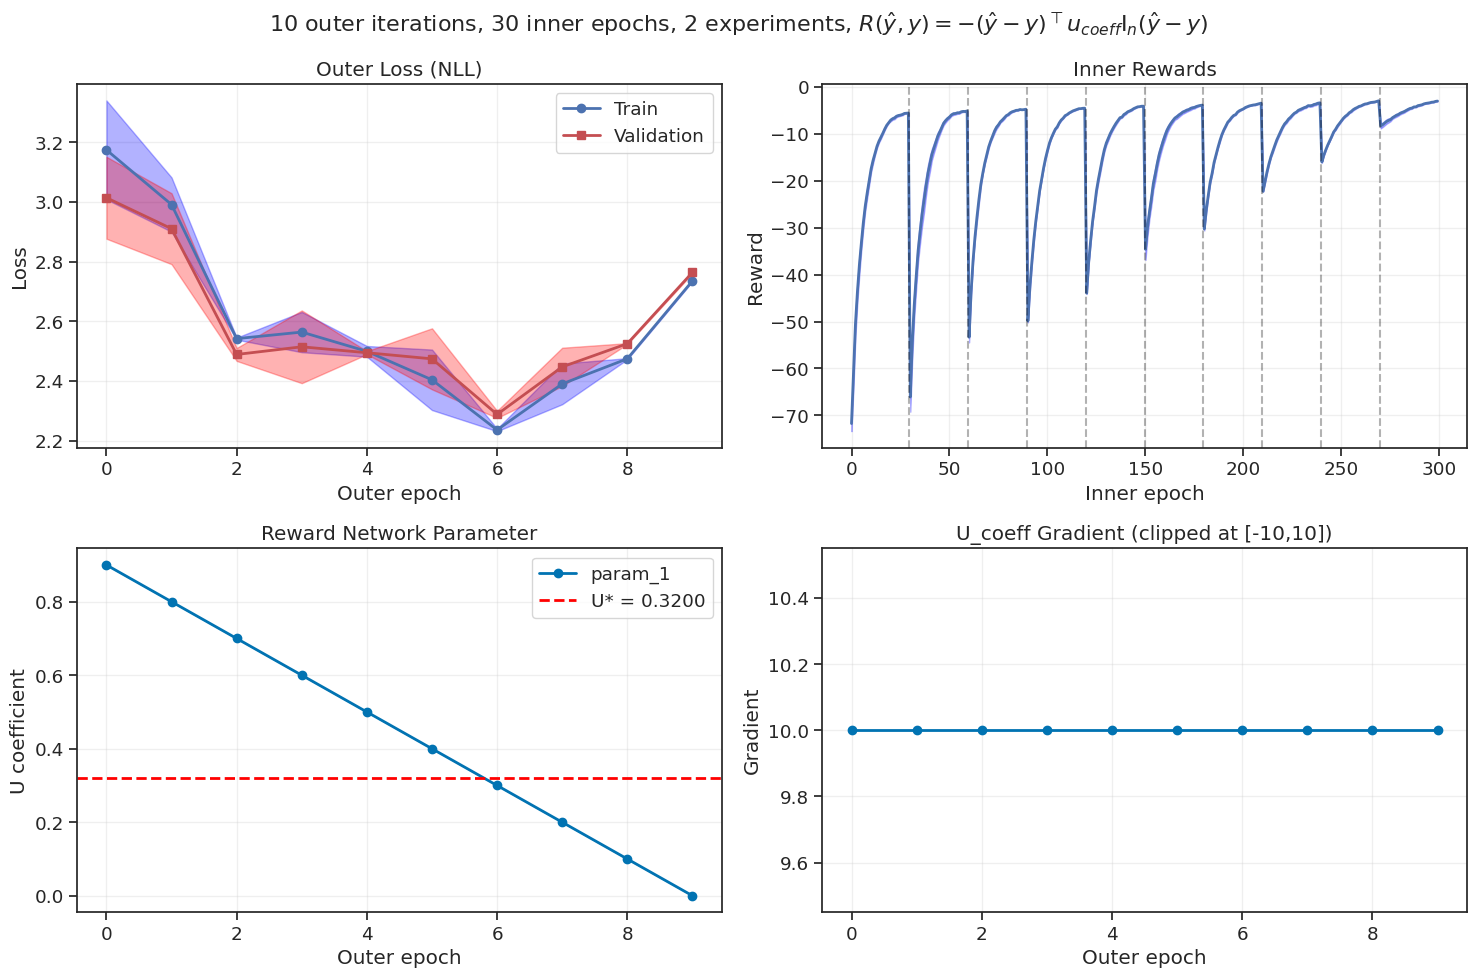

In [14]:
# Plot results with error bars
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Plot outer losses (train and validation)
epochs_outer = range(len(outer_losses_mean))
ax1.plot(
    epochs_outer, outer_losses_mean, "b-o", linewidth=2, markersize=6, label="Train"
)
ax1.fill_between(
    epochs_outer,
    outer_losses_mean - outer_losses_se,
    outer_losses_mean + outer_losses_se,
    alpha=0.3,
    color="blue",
)
ax1.plot(
    epochs_outer,
    val_outer_losses_mean,
    "r-s",
    linewidth=2,
    markersize=6,
    label="Validation",
)
ax1.fill_between(
    epochs_outer,
    val_outer_losses_mean - val_outer_losses_se,
    val_outer_losses_mean + val_outer_losses_se,
    alpha=0.3,
    color="red",
)
ax1.set_xlabel("Outer epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Outer Loss (NLL)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot inner rewards
epochs_inner = range(len(inner_rewards_mean))
ax2.plot(epochs_inner, inner_rewards_mean, "b-", linewidth=2)
ax2.fill_between(
    epochs_inner,
    inner_rewards_mean - inner_rewards_se,
    inner_rewards_mean + inner_rewards_se,
    alpha=0.3,
    color="blue",
)

# Add vertical dotted lines to separate outer epochs
for i in range(1, n_outer_epochs):
    if i * n_inner_epochs < len(epochs_inner):
        ax2.axvline(
            x=i * n_inner_epochs - 0.5, color="black", linestyle="--", alpha=0.3
        )

ax2.set_xlabel("Inner epoch")
ax2.set_ylabel("Reward")
ax2.set_title("Inner Rewards")
ax2.grid(True, alpha=0.3)
# Set integer ticks for x-axis
# ax2.set_xticks(range(0, len(epochs_inner), max(1, len(epochs_inner)//10)))

# Define colors from seaborn default palette
palette = sns.color_palette()  # seaborn default ("deep")
n_params = max(1, len(U_coeff_mean))
colors = [palette[j % len(palette)] for j in range(n_params)]

# Plot U coefficient
for i, (k, v) in enumerate(U_coeff_mean.items()):
    epochs_U = range(len(v))
    color = colors[i % len(colors)]
    if reward_use_softplus:
        ax3.plot(
            epochs_U,
            np.log(1 + np.exp(v)),
            "-o",
            linewidth=2,
            markersize=6,
            label=k,
            color=color,
        )
        ax3.fill_between(
            epochs_U,
            np.log(1 + np.exp(v - U_coeff_se[k])),
            np.log(1 + np.exp(v + U_coeff_se[k])),
            alpha=0.3,
            color=color,
        )
    else:
        ax3.plot(epochs_U, v, "-o", linewidth=2, markersize=6, label=k, color=color)
        ax3.fill_between(
            epochs_U, v - U_coeff_se[k], v + U_coeff_se[k], alpha=0.3, color=color
        )
ax3.axhline(
    y=U_star, color="red", linestyle="--", linewidth=2, label=f"U* = {U_star:.4f}"
)
ax3.set_xlabel("Outer epoch")
ax3.set_ylabel("U coefficient")
ax3.set_title("Reward Network Parameter")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot U coefficient gradients
for i, (k, v) in enumerate(U_coeff_grad_mean.items()):
    color = colors[i % len(colors)]
    epochs_U = range(len(v))
    ax4.plot(epochs_U, v, "-o", linewidth=2, markersize=6, label=k, color=color)
    ax4.fill_between(
        epochs_U, v - U_coeff_grad_se[k], v + U_coeff_grad_se[k], alpha=0.3, color=color
    )
ax4.set_xlabel("Outer epoch")
ax4.set_ylabel("Gradient")
ax4.set_title("U_coeff Gradient (clipped at [-10,10])")
ax4.grid(True, alpha=0.3)


suptitle = f"{n_outer_epochs} outer iterations, {n_inner_epochs} inner epochs, {max_repetitions} experiments, "
suptitle += r"$R(\hat{y},y) = -(\hat{y}-y)^\top u_{coeff} \mathrm{I}_n (\hat{y}-y)$"

fig.suptitle(
    suptitle,
    fontsize=16,
    y=0.98,
)

plt.tight_layout()
plt.show()